In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print("--- Dataset Head ---")
print(df.head())

df["species"] = df["species"].replace({
    "setosa": 0,
    "versicolor": 1,
    "virginica": 2
})

X_lr = df[["sepal_length", "sepal_width", "petal_width"]]
y_lr = df["petal_length"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)


y_pred_lr = lr_model.predict(X_test_lr)

print("\n--- LINEAR REGRESSION EVALUATION ---")
print("Mean Squared Error:", mean_squared_error(y_test_lr, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test_lr, y_pred_lr))
print("R2 Score:", r2_score(y_test_lr, y_pred_lr))

--- Dataset Head ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- LINEAR REGRESSION EVALUATION ---
Mean Squared Error: 0.13001626031382688
Mean Absolute Error: 0.2605179846252386
R2 Score: 0.9603293155857664


/tmp/ipykernel_2127/1768611181.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["species"] = df["species"].replace({


In [ ]:
#Experiment 1: Simple Linear Regression (TV vs. Sales)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None


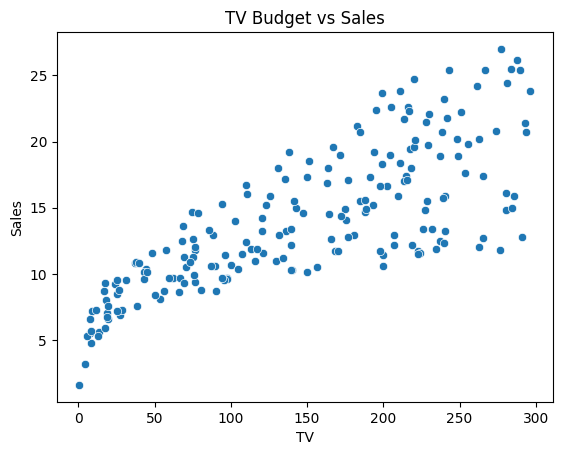

Train shape: (160, 1), Test shape: (40, 1)
Intercept (b0): 7.12
Coefficient (b1): 0.05


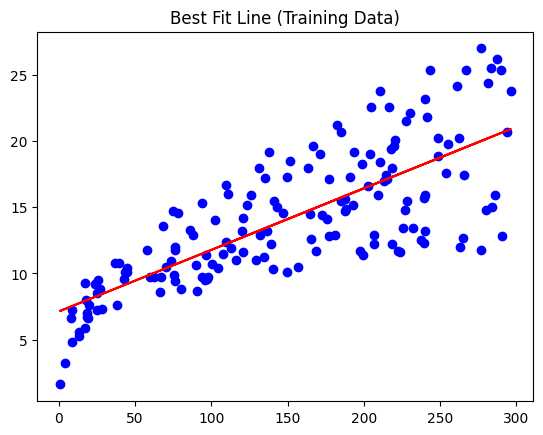

     Actual  Predicted
95     16.9  14.717944
15     22.4  16.211548
30     21.4  20.748197
158     7.3   7.664036
128    24.7  17.370139
RMSE: 3.19, R2 Score: 0.68


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np



df = pd.read_csv('TvMarketing.csv')
print(df.info())


sns.scatterplot(data=df, x='TV', y='Sales')
plt.title("TV Budget vs Sales")
plt.show()


X = df[['TV']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


model = LinearRegression()
model.fit(X_train, y_train)
print(f"Intercept (b0): {model.intercept_:.2f}")
print(f"Coefficient (b1): {model.coef_[0]:.2f}")

plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, model.predict(X_train), color='red') # Best fit line
plt.title("Best Fit Line (Training Data)")
plt.show()


y_pred = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

In [ ]:
#Experiment 2: Multiple Linear Regression (CO2 Emissions)

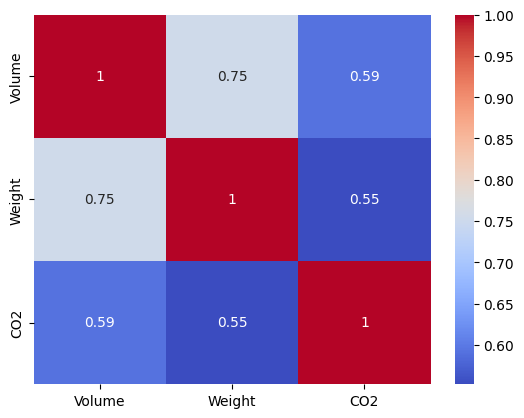

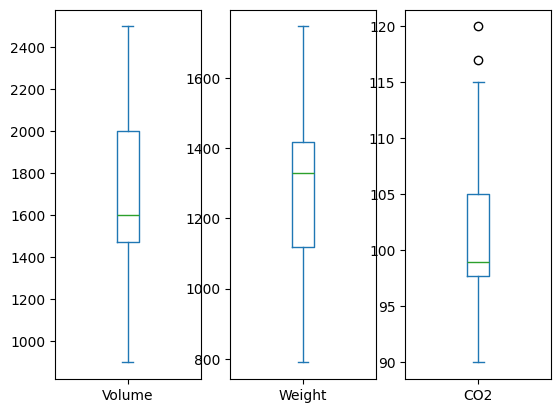

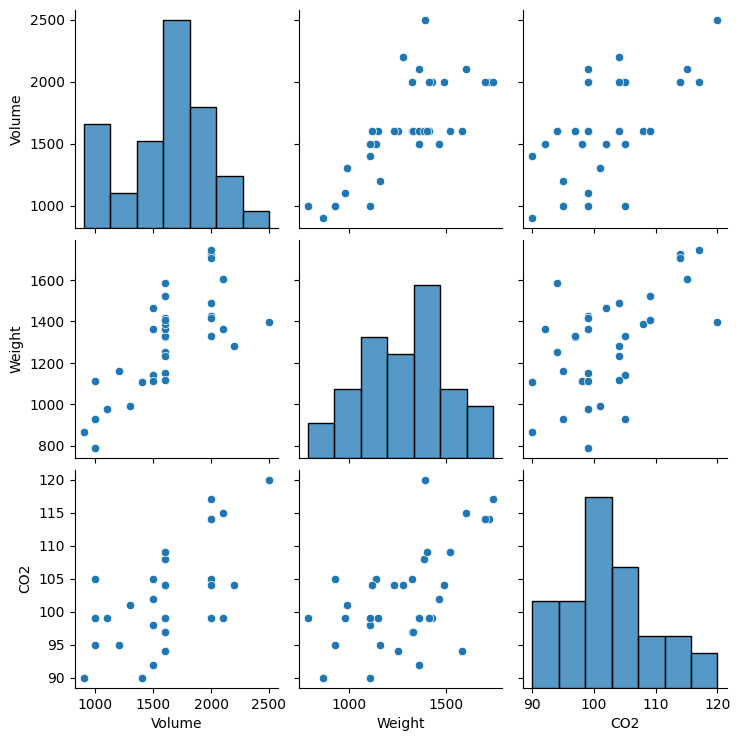

Coefficients: [0.00428741 0.00804928]
Intercept: 84.21502006695282


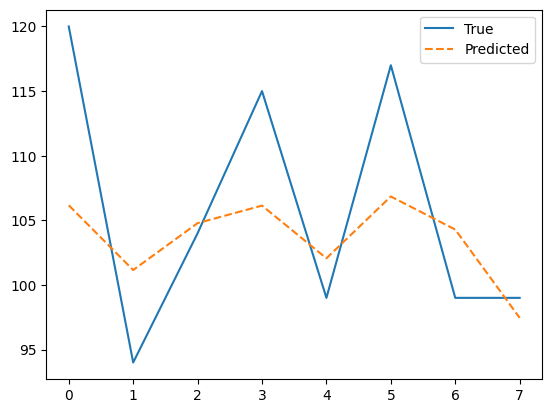

MAE: 6.335639624274503
MSE: 58.07928583657771
RMSE: 7.620976698335832


In [ ]:
df_cars = pd.read_csv('DATA.csv')

sns.heatmap(df_cars[['Volume', 'Weight', 'CO2']].corr(), annot=True, cmap='coolwarm')
plt.show()

df_cars[['Volume', 'Weight', 'CO2']].plot(kind='box', subplots=True, layout=(1,3))
plt.show()

sns.pairplot(df_cars[['Volume', 'Weight', 'CO2']])
plt.show()

X = df_cars[['Volume', 'Weight']]
y = df_cars['CO2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Coefficients:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)

y_pred = model_multi.predict(X_test)
plt.plot(range(len(y_test)), y_test.values, label='True')
plt.plot(range(len(y_pred)), y_pred, label='Predicted', linestyle='--')
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
#Experiment 3: Logistic Regression (Ad Click Prediction)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_ad = pd.read_csv('advertising.csv')

X = df_ad[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y = df_ad['Clicked on Ad']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results = cross_val_score(log_model, X_scaled, y, cv=kfold)

print(f"K-fold Cross-Validation Accuracy: {results.mean():.2f}")

y_pred = log_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

K-fold Cross-Validation Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

